# Dataset 2 - LMS-Based Connectivity Features using FP1 Reference

This notebook investigates schizophrenia detection on Dataset 2 using connectivity features extracted after LMS filtering with FP1 as the reference channel.

In [ ]:
import os
import zipfile
import numpy as np
import mne
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

from PyEMD import EMD

from scipy.signal import resample as sciresample
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_val_score

In [ ]:
subsets = ["subset_1.zip", "subset_2.zip", "subset_3.zip"]
base_dir = "/content"

for subset_zip in subsets:
    with zipfile.ZipFile(os.path.join(base_dir, subset_zip), 'r') as zip_ref:
        zip_ref.extractall(base_dir)
        print(f"Contenu extrait pour {subset_zip}")

Contenu extrait pour subset_1.zip
Contenu extrait pour subset_2.zip
Contenu extrait pour subset_3.zip


In [ ]:
def extract_category_from_gnr(gnr_path):
    try:
        with open(gnr_path, 'r') as f:
            for line in f:
                if line.startswith("category="):
                    cat_value = line.split("=")[1].strip()
                    if cat_value in ["Patient", "Control"]:
                        return cat_value
        return None
    except Exception as e:
        print(f"Erreur lecture {gnr_path}: {e}")
        return None

In [ ]:
def unify_channels(signal, desired_channels=24):

    n_channels, n_times = signal.shape
    if n_channels < desired_channels:
        new_signal = np.zeros((desired_channels, n_times), dtype=signal.dtype)
        new_signal[:n_channels, :] = signal
        return new_signal
    elif n_channels > desired_channels:
        print(f"Tronquage de {n_channels} canaux à {desired_channels} canaux.")
        return signal[:desired_channels, :]
    else:
        return signal

In [ ]:
def my_resample(signal, old_fs, target_fs=250):
    if abs(old_fs - target_fs) < 1e-9:
        return signal, old_fs

    n_channels, n_times_old = signal.shape
    n_times_new = int(n_times_old * (target_fs / old_fs))

    resampled = np.zeros((n_channels, n_times_new), dtype=signal.dtype)
    for ch in range(n_channels):
        resampled[ch, :] = sciresample(signal[ch, :], n_times_new)

    return resampled, target_fs

In [ ]:
def segment_signal(signal, fs, window_size=10, overlap=0.5):

    window_samples = int(window_size * fs)
    step = int(window_samples * (1 - overlap))
    segments = []
    for start in range(0, signal.shape[1] - window_samples + 1, step):
        seg = signal[:, start:start+window_samples]
        segments.append(seg)
    return segments

In [ ]:
def emd_channel(channel_data, max_imf=5):

    emd = EMD()
    imfs = emd(channel_data)
    if imfs.shape[0] > max_imf:
        imfs = imfs[:max_imf, :]
    return imfs

**LMS+PLI+PLV**

In [ ]:
def compute_phases_multichannel(segment_filtered):

    n_channels, n_samples = segment_filtered.shape
    phases = np.zeros((n_channels, n_samples))
    for ch in range(n_channels):
        analytic = hilbert(segment_filtered[ch, :])
        phases[ch, :] = np.angle(analytic)
    return phases

In [ ]:
def compute_plv(phase1, phase2):
    phase_diff = phase1 - phase2
    return np.abs(np.mean(np.exp(1j * phase_diff)))

def compute_pli(phase1, phase2):
    phase_diff = phase1 - phase2
    return np.abs(np.mean(np.sign(np.sin(phase_diff))))


In [ ]:
def compute_plv_pli_features(phases):
    n_channels, n_samples = phases.shape
    feats = []
    for ch1 in range(n_channels):
        for ch2 in range(ch1+1, n_channels):
            plv_val = compute_plv(phases[ch1,:], phases[ch2,:])
            pli_val = compute_pli(phases[ch1,:], phases[ch2,:])
            feats.extend([plv_val, pli_val])
    return np.array(feats)

In [ ]:
def build_dataset_plv_pli_lms_fp1(base_dir,
                                  subsets=["subset_1","subset_2","subset_3"],
                                  fp1_index=0,
                                  desired_channels=24,
                                  target_fs=256,
                                  window_size=10,
                                  overlap=0.5,
                                  mu=0.005,
                                  filter_len=10):
 
    X = []
    y = []

    subfolders = ["1","2","3"]

    for subset_name in subsets:
        subset_folder = os.path.join(base_dir, subset_name)
        if not os.path.isdir(subset_folder):
            continue

        for subject in os.listdir(subset_folder):
            subject_dir = os.path.join(subset_folder, subject)
            if not os.path.isdir(subject_dir):
                continue

            category = None
            for sf in subfolders:
                sf_path = os.path.join(subject_dir, sf)
                if not os.path.isdir(sf_path):
                    continue
                gnr_file = None
                for f in os.listdir(sf_path):
                    if f.lower().endswith(".gnr"):
                        gnr_file = os.path.join(sf_path, f)
                        break
                if gnr_file:
                    cat = extract_category_from_gnr(gnr_file)
                    if cat in ["Patient","Control"]:
                        category = cat
                        break

            if category is None:
                continue
            label = 1 if category=="Patient" else 0

            for sf in subfolders:
                sf_path = os.path.join(subset_folder, subject, sf)
                if not os.path.isdir(sf_path):
                    continue

                for f in os.listdir(sf_path):
                    if f.lower().endswith(".edf"):
                        edf_path = os.path.join(sf_path, f)
                        try:
                            raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


                            data = raw.get_data()
                            old_fs = raw.info['sfreq']

                            data = unify_channels(data, desired_channels)

                            data_rs, fs_rs = my_resample(data, old_fs, target_fs)

                            segments = segment_signal(data_rs, fs_rs,
                                                      window_size=window_size,
                                                      overlap=overlap)

                            for seg in segments:
                                seg_filtered = lms_filter_with_reference_FP1_multichannel(
                                    seg,
                                    fp1_index=fp1_index,
                                    mu=mu,
                                    filter_len=filter_len
                                )

                                phases = compute_phases_multichannel(seg_filtered)
                                feats = compute_plv_pli_features(phases)
                                X.append(feats)
                                y.append(label)

                        except Exception as e:
                            print(f"Erreur lecture {edf_path}: {e}")

    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
base_dir = "/content"
subsets = ["subset_1","subset_2","subset_3"]

fp1_index = 0       
desired_channels = 24
target_fs = 256
window_size = 10
overlap = 0.5
mu = 0.005
filter_len = 10

X, y = build_dataset_plv_pli_lms_fp1(
    base_dir=base_dir,
    subsets=subsets,
    fp1_index=fp1_index,
    desired_channels=desired_channels,
    target_fs=target_fs,
    window_size=window_size,
    overlap=overlap,
    mu=mu,
    filter_len=filter_len
)

print("X shape:", X.shape)  
print("y shape:", y.shape)

X shape: (3805, 552)
y shape: (3805,)


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       374
           1       0.81      0.96      0.88       387

    accuracy                           0.86       761
   macro avg       0.88      0.86      0.86       761
weighted avg       0.88      0.86      0.86       761



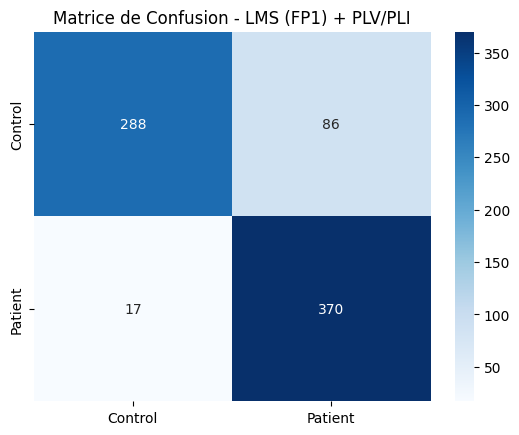

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control","Patient"], yticklabels=["Control","Patient"])
plt.title("Matrice de Confusion - LMS (FP1) + PLV/PLI")
plt.show()